# Non-Uniform Azimuthal Poisson Solver: $N$ vs. $M$ Analysis & Disk Error Comparisons

This notebook evaluates the **Adapted NUFFT**, **Adapted NUDFT**, and **Uniform FFT** solvers on a disk $\mathcal{B}(0, R)$ for a Poisson problem with a localized high-frequency azimuthal wave packet:
$$
u(r, \theta) = r^2 \left(R^2 - r^2\right) \frac{\cos(k \theta)}{1 - \gamma \cos(\theta - \theta_0)}
$$
with $k=4$, sharpness $\gamma = 0.65$, and homogeneous Dirichlet boundary conditions $u(R, \theta) = 0$.

## 1. Configurable Parameters & Setup
All problem, mesh, and solver parameters are configured in the cell below:

In [8]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure project root is in path
repo_root = r"c:\Users\charl\NUFFTRR_Poisson"
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

from Tests.paper.helpers import (
    get_azimuthal_benchmark_problem,
    generate_adapted_clustered_azimuthal,
    run_benchmark_case,
    run_all_algorithms_NxM_study,
    render_algorithm_tables,
    plot_solution_and_grids,
    plot_accuracy_and_runtimes_from_df,
    plot_3x3_disk_error_comparison,
    plot_adapted_vs_highres_uniform
)

# =========================================================================
# Configurable Problem & Grid Parameters
# =========================================================================
R = 1.0                     # Disk radius
THETA_0 = np.pi             # Center angle of localized feature (radians)
K_MODE = 4                  # Azimuthal wave frequency
GAMMA = 0.65                # Angular sharpness parameter in [0, 1)

# Solver & Radial Grid Settings
QUAD_RULE = 2               # 1: Trapezoidal, 2: Simpson's rule
BC_CHOICE = 1               # 1: Dirichlet, 2: Neumann
CLUSTER_STRENGTH = 0.40     # Angular clustering factor in [0, 1)

# N vs M Sweep Grids
N_VALUES = [16, 24, 32, 48, 64, 128]
M_VALUES = [16, 32, 64, 128, 256]

# High-Resolution Uniform Comparison Settings
N_LOW_ADAPT = 32
N_HIGH_UNIFORM = 256
M_FIXED_PLOTS = 64

## 2. Problem Setup and Disk Grid Visualization
3D analytical solution $u(x,y)$ on the disk, clean polar grid comparison, and 1D angular slice profile.

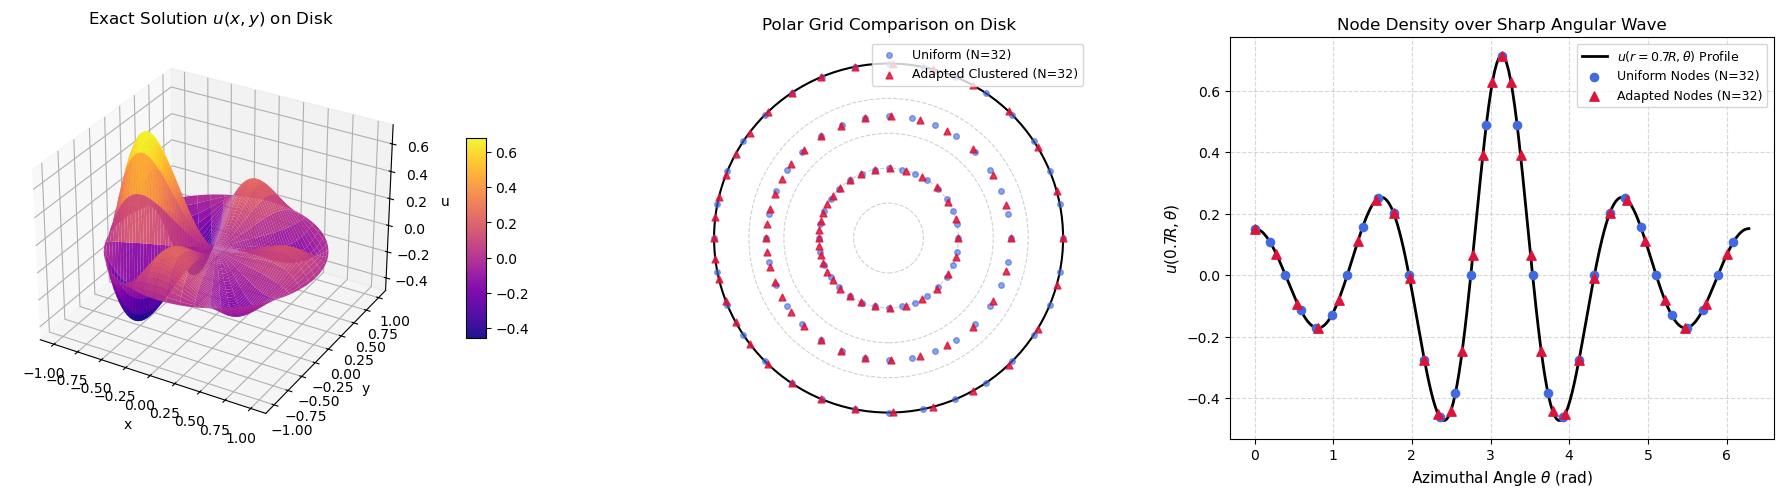

In [9]:
# Construct benchmark problem
problem = get_azimuthal_benchmark_problem(
    R=R, theta_0=THETA_0, k_mode=K_MODE, gamma=GAMMA
)

# Visualize 3D solution surface and 2D polar lattice
plot_solution_and_grids(
    problem=problem,
    N_adapt=32,
    N_unif=32,
    M=M_FIXED_PLOTS,
    cluster_strength=CLUSTER_STRENGTH,
    theta_0=THETA_0
)

## 3. $N$ vs. $M$ Grid Study for All Three Algorithms
We compute the full $(N \times M)$ matrix of relative $L_2$ errors and execution times for **Adapted NUFFT**, **Adapted NUDFT**, and **Uniform FFT**.

In [10]:
df_results = run_all_algorithms_NxM_study(
    problem=problem,
    N_values=N_VALUES,
    M_values=M_VALUES,
    cluster_strength=CLUSTER_STRENGTH,
    theta_0=THETA_0,
    bc_choice=BC_CHOICE,
    quad_rule=QUAD_RULE
)

Computing N vs M Grid Matrix: 100%|██████████| 90/90 [00:05<00:00, 16.05it/s]


## 4. $L_2$ Error & Runtime Tables ($N$ vs. $M$)
Relative $L_2$ error tables for each algorithm across $N$ (rows) and $M$ (columns).

In [11]:
# Relative L2 Error Tables for each algorithm
error_tables = render_algorithm_tables(df_results, value_col="L2_rel", format_sci=True)

# Runtime (seconds) Tables for each algorithm
runtime_tables = render_algorithm_tables(df_results, value_col="runtime", format_sci=False)


Adapted NUFFT — Relative L₂ Error (N vs M)


M,16,32,64,128,256
N,,,,,
16,3.39e-01,3.40e-01,3.40e-01,3.40e-01,3.40e-01
24,2.80e-02,2.83e-02,2.84e-02,2.84e-02,2.84e-02
32,3.64e-03,3.10e-03,3.10e-03,3.10e-03,3.10e-03
48,2.12e-03,2.38e-04,2.84e-05,4.92e-06,3.56e-06
64,2.12e-03,2.38e-04,2.84e-05,5.21e-06,3.95e-06
128,2.14e-03,3.21e-04,2.21e-04,2.20e-04,1.55e-01



Adapted NUDFT — Relative L₂ Error (N vs M)


M,16,32,64,128,256
N,,,,,
16,3.39e-01,3.40e-01,3.40e-01,3.40e-01,3.40e-01
24,2.80e-02,2.83e-02,2.84e-02,2.84e-02,2.84e-02
32,3.64e-03,3.10e-03,3.10e-03,3.10e-03,3.10e-03
48,2.13e-03,2.42e-04,5.01e-05,4.16e-05,4.15e-05
64,2.12e-03,2.38e-04,2.82e-05,3.47e-06,7.24e-07
128,2.12e-03,2.38e-04,2.82e-05,3.42e-06,4.26e-07



Uniform FFT — Relative L₂ Error (N vs M)


...

M,16,32,64,128,256
N,,,,,
16,0.0567,0.0546,0.0529,0.0523,0.0729
24,0.0830,0.0910,0.0978,0.0940,0.1291
32,0.0593,0.0712,0.0716,0.0550,0.0770
48,0.0933,0.1283,0.1423,0.1188,0.1564
64,0.0614,0.1069,0.0775,0.0577,0.0812
128,0.1207,0.1131,0.1186,0.1681,0.4626



Adapted NUDFT — Runtime (s) (N vs M)


M,16,32,64,128,256
N,,,,,
16,0.0436,0.0377,0.0416,0.0360,0.0459
24,0.0276,0.0235,0.0261,0.0259,0.0354
32,0.0167,0.0191,0.0198,0.0264,0.0341
48,0.0294,0.0253,0.0301,0.0320,0.0429
64,0.0192,0.0184,0.0195,0.0259,0.0396
128,0.0754,0.0723,0.0760,0.0852,0.0975



Uniform FFT — Runtime (s) (N vs M)


M,16,32,64,128,256
N,,,,,
16,0.0029,0.0015,0.0019,0.0016,0.0020
24,0.0021,0.0020,0.0033,0.0020,0.0028
32,0.0039,0.0029,0.0033,0.0020,0.0030
48,0.0019,0.0022,0.0031,0.0039,0.0042
64,0.0019,0.0017,0.0021,0.0029,0.0044
128,0.0020,0.0017,0.0046,0.0059,0.0089


## 5. Convergence & Runtime Curves
Plots of Accuracy vs. $N$ (fixed $M$), Accuracy vs. $M$ (fixed $N$), and Runtime vs. $N$ for all three algorithms.

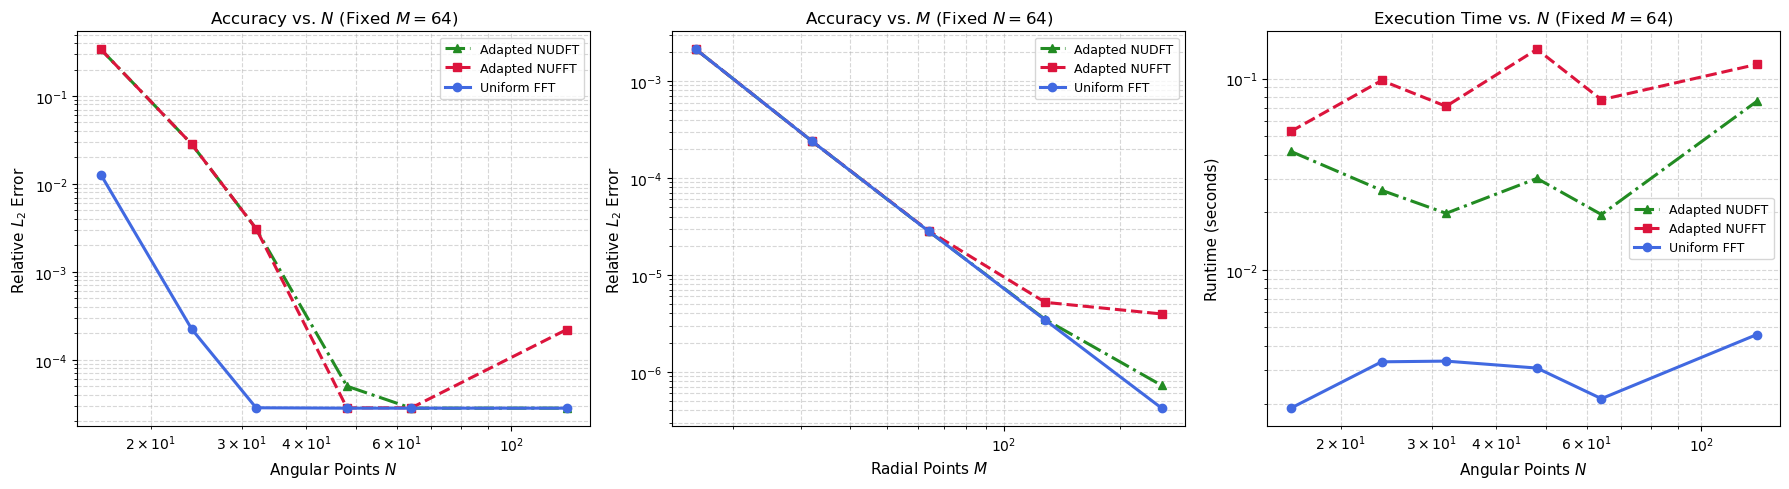

In [12]:
plot_accuracy_and_runtimes_from_df(
    df_results=df_results,
    fixed_M=M_FIXED_PLOTS,
    fixed_N=64
)

## 6. $3 \times 3$ Disk Error Comparison (Equal Resolution)
3D pointwise error surfaces on the disk at equal resolutions across:
- **Rows:** $N = 32, 64, 128$
- **Columns:** Adapted NUFFT | Adapted NUDFT | Uniform FFT

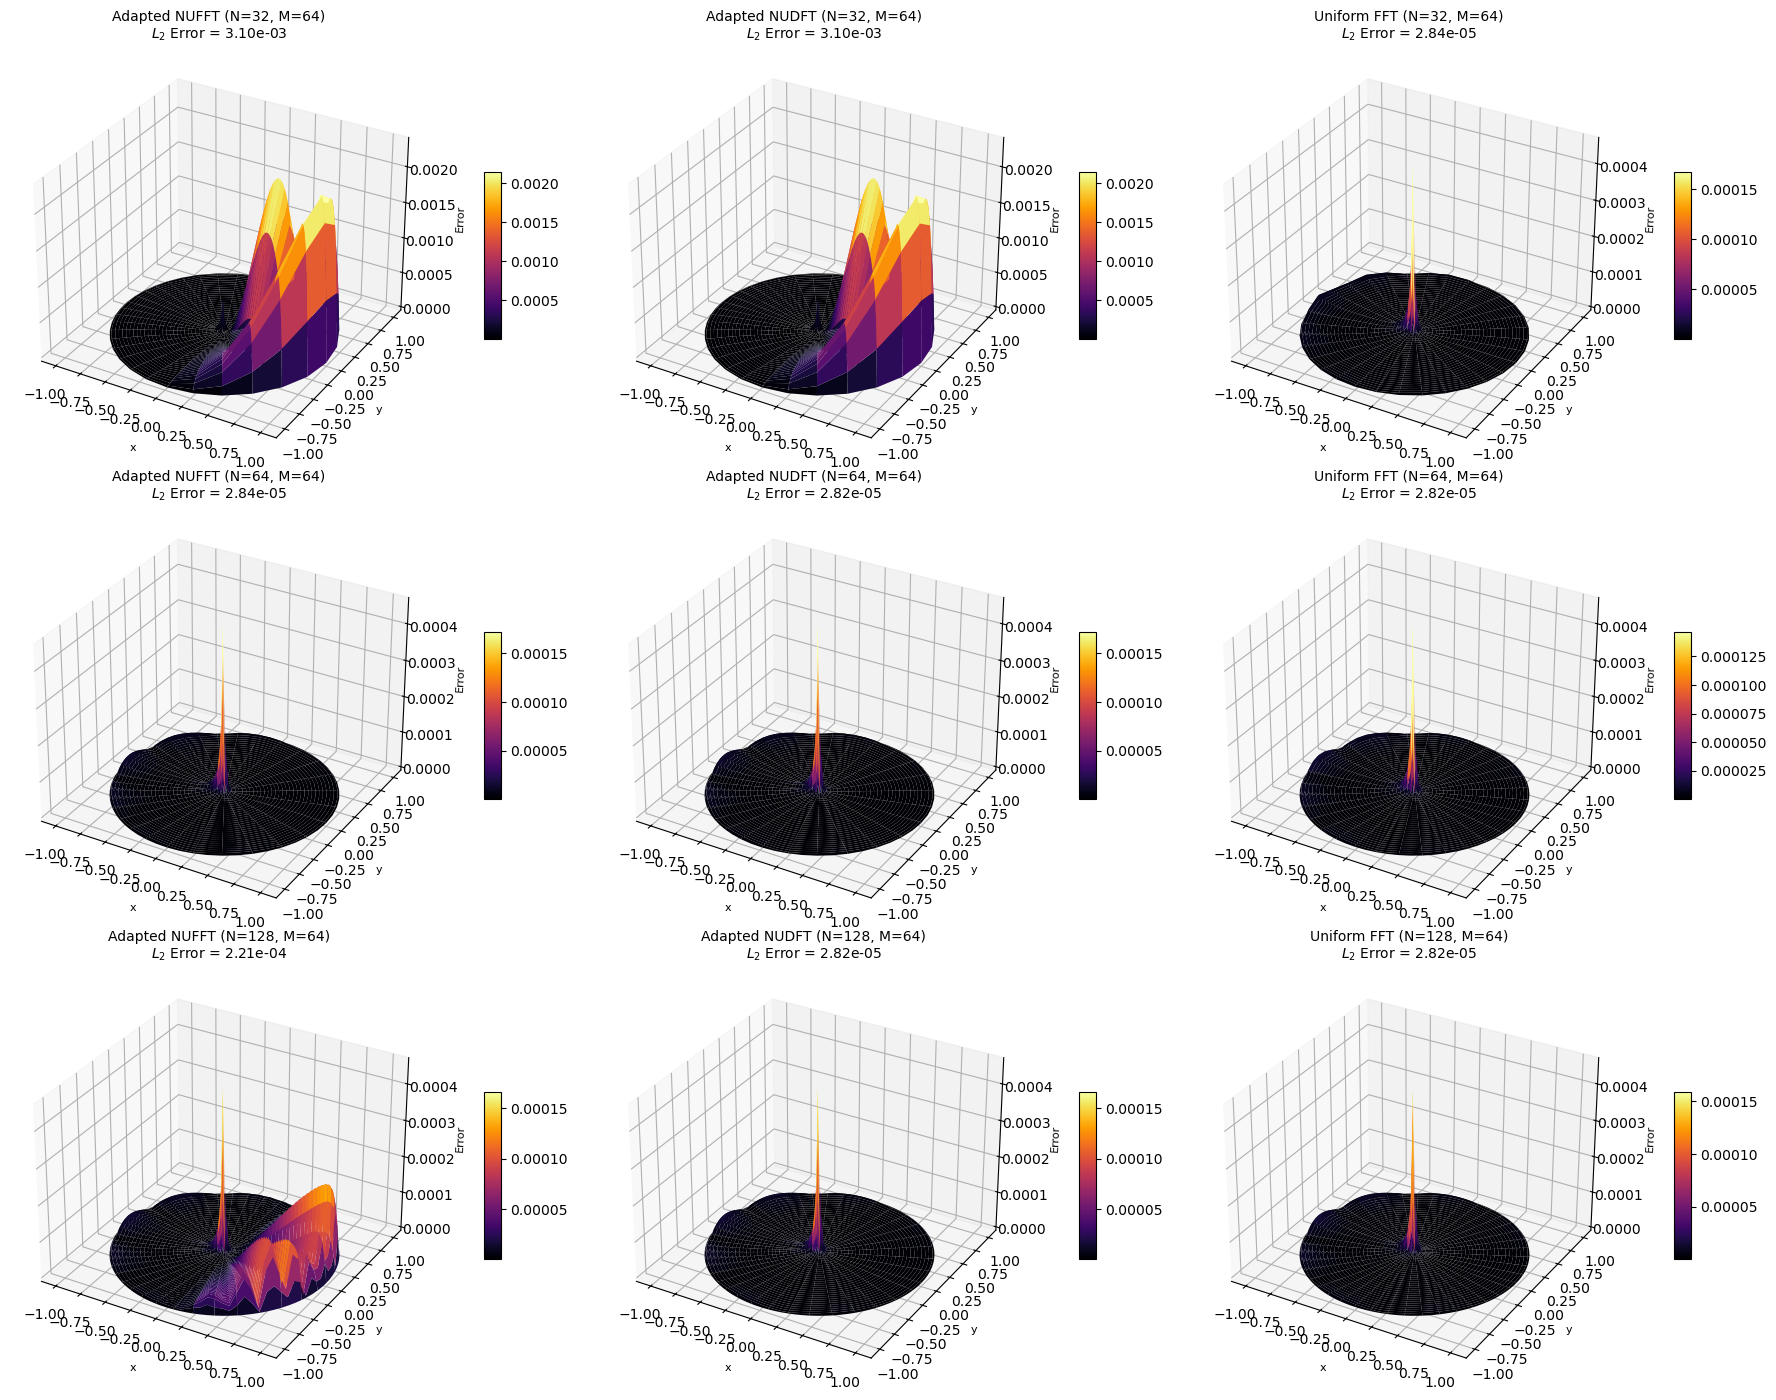

In [13]:
plot_3x3_disk_error_comparison(
    problem=problem,
    N_list=[32, 64, 128],
    M=M_FIXED_PLOTS,
    cluster_strength=CLUSTER_STRENGTH,
    theta_0=THETA_0,
    quad_rule=QUAD_RULE,
    bc_choice=BC_CHOICE
)

## 7. Disk Error Comparison with Higher-Resolution Uniform Grid
Side-by-side 3D error surfaces comparing Adapted NUFFT ($N=32$) and Adapted NUDFT ($N=32$) against the higher-resolution Uniform FFT ($N=256$).

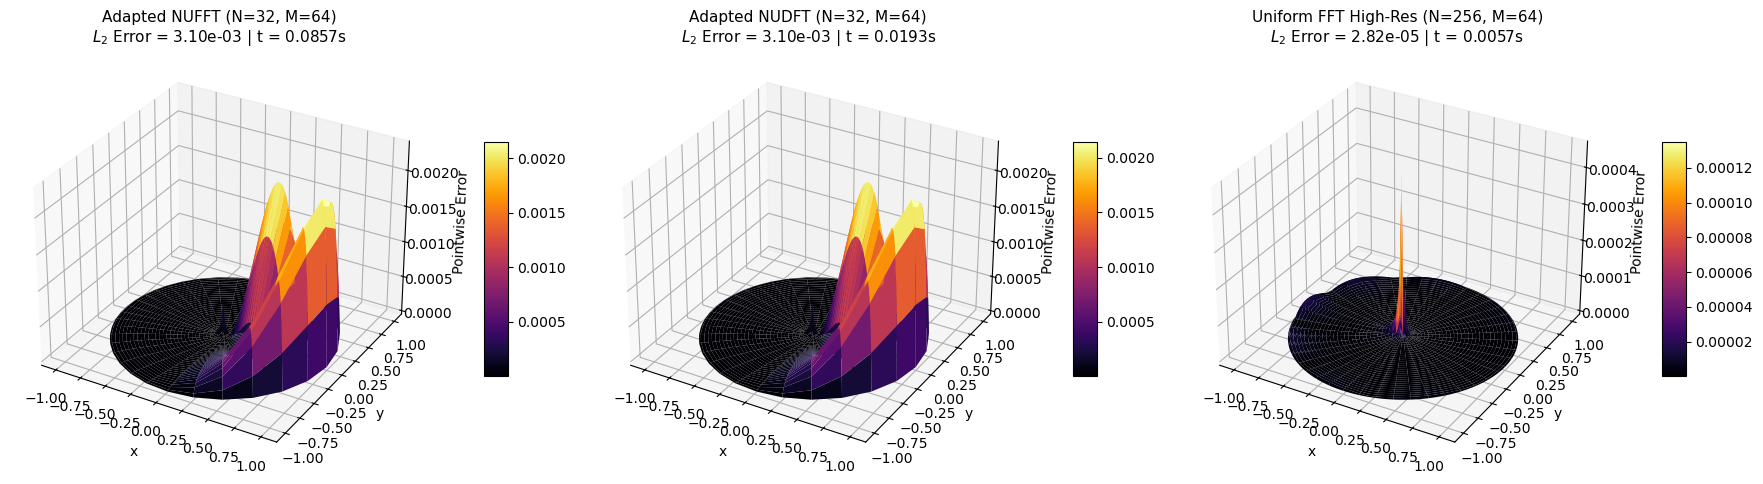

In [14]:
plot_adapted_vs_highres_uniform(
    problem=problem,
    N_adapt=N_LOW_ADAPT,
    N_unif_high=N_HIGH_UNIFORM,
    M=M_FIXED_PLOTS,
    cluster_strength=CLUSTER_STRENGTH,
    theta_0=THETA_0,
    quad_rule=QUAD_RULE,
    bc_choice=BC_CHOICE
)